# [Hands-On] Complete Decoder Layer in GPT-OSS 20B

- Author: Sangkeun Jung (hugmanskj@gmail.com)

> Educational Purpose

**Copyright**: All rights reserved

---

## Overview

In this hands-on tutorial, we will build a **complete Transformer Decoder Layer** by combining
all the components we've learned so far and adding the missing piece: **Mixture of Experts (MoE)**.

We will:

- Understand MoE: Router + Experts architecture
- Implement RMSNorm (Root Mean Square Layer Normalization)
- Build the MoE FFN with Top-K routing
- Learn about interleaved storage patterns (critical for correctness!)
- Combine Attention + MoE + Normalization + Residual connections
- Verify complete decoder layer matches HuggingFace exactly

This is the culmination of everything we've learned - a fully functional transformer layer!

## 1. Theoretical Foundation

### What is Mixture of Experts (MoE)?

**Traditional Feed-Forward Network:**

```
Input → Single Large FFN → Output

Problem:
- Same network processes all inputs
- Hard to specialize for different patterns
- Inefficient parameter usage
```

**Mixture of Experts:**

```
Input → Router (Gatekeeper)
         ↓
    Expert 0 (Math specialist)
    Expert 1 (Science specialist)  ← Selected!
    Expert 2 (History specialist)
    Expert 3 (Literature specialist)
         ↓
      Weighted average → Output

Advantages:
- Specialization: Each expert learns different patterns
- Efficiency: Only activate selected experts
- Scalability: Add more experts to increase capacity
```

### Real-World Analogy: Hospital System

```
Patient → Reception desk (Router)
           ↓
       Orthopedics (Expert 0)
       Internal Medicine (Expert 1)  ← Route based on symptoms
       Dermatology (Expert 2)
       Dentistry (Expert 3)

Each department specializes in their domain!
```

### GPT-OSS MoE Architecture

```
Configuration:
- Number of experts: 32 (typical)
- Top-K: Use K best experts per token (usually 2)
- Router: Learnable weights to select experts

Benefits:
- Same compute, more parameters
- Each expert learns different linguistic patterns
- Better model capacity
```

### Complete Decoder Layer Structure

```
Input (hidden_states)
  ↓
┌─────────────────────┐
│ Input RMSNorm       │  ← Pre-normalization
└─────────────────────┘
  ↓
┌─────────────────────┐
│ Self-Attention      │  ← Q/K/V + RoPE + GQA + Sinks
└─────────────────────┘
  ↓
  + (Residual 1)
  ↓
┌─────────────────────┐
│ Post-Attn RMSNorm   │  ← Pre-normalization
└─────────────────────┘
  ↓
┌─────────────────────┐
│ Router              │  ← Select Top-K experts
└─────────────────────┘
  ↓
┌─────────────────────┐
│ Experts (parallel)  │  ← MoE FFN computation
└─────────────────────┘
  ↓
  + (Residual 2)
  ↓
Output (hidden_states)
```

### RMSNorm: Efficient Normalization

**Standard LayerNorm:**

$$
y = \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}}
$$

**RMSNorm (Root Mean Square):**

$$
\text{RMS}(x) = \sqrt{\frac{1}{d} \sum_{i=1}^{d} x_i^2}
$$

$$
y = \frac{x}{\text{RMS}(x) + \epsilon} \cdot \gamma
$$

where $\gamma$ is learnable gain parameter.

**Advantages:**
- Faster computation (no mean calculation)
- Similar performance to LayerNorm
- Better numerical stability

### Gated Activation Function

GPT-OSS uses a special gated activation:

```python
gate = gate_proj(x)
up = up_proj(x)

glu = gate * sigmoid(gate * alpha)
output = (up + 1) * glu
```

**Key features:**
- Clamping for numerical stability
- Special alpha scaling (1.702)
- Residual-like connection with (up + 1)

---

## 2. Import Libraries and Helper Functions

In [ ]:
import sys
import math
from typing import Optional, Tuple
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
from huggingface_hub.errors import HfHubHTTPError, RepositoryNotFoundError


def set_seed(seed: int = 42):
    """Set random seed for reproducibility"""
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def format_tensor_slice(tensor: torch.Tensor, limit: int = 8) -> str:
    """Format tensor values for readable display"""
    flat = tensor.flatten()
    elems = flat[:limit].tolist()
    pieces = ", ".join(f"{x:.4f}" for x in elems)
    return f"{pieces}, ..." if flat.numel() > limit else pieces


def load_with_token(load_fn, token: str | None, **kwargs):
    """Load model/tokenizer with authentication token"""
    auth_kwargs = {"token": token} if token else {}
    try:
        return load_fn(**auth_kwargs, **kwargs)
    except TypeError:
        auth_kwargs = {"use_auth_token": token} if token else {}
        return load_fn(**auth_kwargs, **kwargs)


def repeat_kv(hidden_states: torch.Tensor, n_rep: int) -> torch.Tensor:
    """
    Repeat key/value tensors for Grouped Query Attention.

    Args:
        hidden_states: [batch, num_kv_heads, seq_len, head_dim]
        n_rep: Number of times to repeat

    Returns:
        [batch, num_kv_heads * n_rep, seq_len, head_dim]
    """
    batch, num_kv_heads, seq_len, head_dim = hidden_states.shape
    if n_rep == 1:
        return hidden_states

    hidden_states = hidden_states[:, :, None, :, :].expand(
        batch, num_kv_heads, n_rep, seq_len, head_dim
    )
    return hidden_states.reshape(batch, num_kv_heads * n_rep, seq_len, head_dim)


print("Libraries and helper functions loaded successfully!")

Libraries and helper functions loaded successfully!


---

## 3. Configuration and Settings

In [ ]:
# ============================================================
# Configuration
# ============================================================

# Model settings
MODEL_NAME = "openai/gpt-oss-20b"
DTYPE_STR = "bfloat16"
DEVICE_MAP = "auto"
HF_TOKEN = None

# Test input
PROMPT = "hello gpt"

# Seed for reproducibility
SEED = 42

# Device selection
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    DEVICE = torch.device("cpu")
    print("Using CPU (Warning: This will be slow)")

# Data type mapping
DTYPE_MAP = {
    "float16": torch.float16,
    "bfloat16": torch.bfloat16,
    "float32": torch.float32,
}

if DTYPE_STR not in DTYPE_MAP:
    raise ValueError(f"Unknown dtype: {DTYPE_STR}. Available: {list(DTYPE_MAP.keys())}")

TORCH_DTYPE = DTYPE_MAP[DTYPE_STR]

# Set seed
set_seed(SEED)

print(f"Configuration:")
print(f"  Model: {MODEL_NAME}")
print(f"  Prompt: '{PROMPT}'")
print(f"  Data type: {TORCH_DTYPE}")
print(f"  Device: {DEVICE}")
print(f"  Seed: {SEED}")

Using CPU (Warning: This will be slow)
Configuration:
  Model: openai/gpt-oss-20b
  Prompt: 'hello gpt'
  Data type: torch.bfloat16
  Device: cpu
  Seed: 42


---

## 4. Reusing Components from Previous Tutorials

We build incrementally! Below are implementations from previous tutorials:
- **CustomTokenEmbedding**: from Tutorial 01
- **CustomRotaryEmbedding**: from Tutorial 02
- **CustomCausalMask**: from Tutorial 02
- **CustomSelfAttention**: from Tutorial 03

In [ ]:
# ============================================================
# REUSED FROM TUTORIAL 01: CustomTokenEmbedding
# ============================================================

class CustomTokenEmbedding(nn.Module):
    """Custom implementation of token embedding layer."""

    def __init__(
        self,
        vocab_size: int,
        hidden_size: int,
        dtype: torch.dtype = torch.float32,
        device: torch.device | None = None,
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.weight = nn.Parameter(
            torch.empty(vocab_size, hidden_size, dtype=dtype, device=device)
        )
        with torch.no_grad():
            nn.init.normal_(self.weight, mean=0.0, std=0.02)

    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:
        return torch.embedding(self.weight, input_ids)

    @classmethod
    def from_pretrained(cls, reference_embedding_layer):
        vocab_size, hidden_size = reference_embedding_layer.weight.shape
        dtype = reference_embedding_layer.weight.dtype
        device = reference_embedding_layer.weight.device
        custom_embedding = cls(vocab_size, hidden_size, dtype, device)
        with torch.no_grad():
            custom_embedding.weight.copy_(reference_embedding_layer.weight)
        return custom_embedding

In [ ]:
# ============================================================
# REUSED FROM TUTORIAL 02: CustomRotaryEmbedding
# ============================================================

class CustomRotaryEmbedding(nn.Module):
    """Custom implementation of Rotary Position Embedding with YaRN scaling."""

    def __init__(
        self,
        head_dim: int,
        base: float = 10000.0,
        dtype: torch.dtype = torch.float32,
        initial_context_length: int = 4096,
        scaling_factor: float = 1.0,
        ntk_alpha: float = 1.0,
        ntk_beta: float = 32.0,
        device: torch.device | None = None,
    ):
        super().__init__()
        self.head_dim = head_dim
        self.base = base
        self.dtype = dtype
        self.initial_context_length = initial_context_length
        self.scaling_factor = scaling_factor
        self.ntk_alpha = ntk_alpha
        self.ntk_beta = ntk_beta
        self.device = device

    def _compute_concentration_and_inv_freq(self):
        freq = self.base ** (
            torch.arange(0, self.head_dim, 2, dtype=torch.float32, device=self.device)
            / self.head_dim
        )

        if self.scaling_factor > 1.0:
            concentration = 0.1 * math.log(self.scaling_factor) + 1.0
            d_half = self.head_dim / 2
            low = (
                d_half
                * math.log(self.initial_context_length / (self.ntk_beta * 2 * math.pi))
                / math.log(self.base)
            )
            high = (
                d_half
                * math.log(self.initial_context_length / (self.ntk_alpha * 2 * math.pi))
                / math.log(self.base)
            )
            interpolation = 1.0 / (self.scaling_factor * freq)
            extrapolation = 1.0 / freq
            ramp = (
                torch.arange(d_half, dtype=torch.float32, device=freq.device) - low
            ) / (high - low)
            mask = 1 - ramp.clamp(0, 1)
            inv_freq = interpolation * (1 - mask) + extrapolation * mask
        else:
            concentration = 1.0
            inv_freq = 1.0 / freq

        return concentration, inv_freq

    def forward(self, value_states, position_ids):
        """Generate RoPE cos/sin for given positions."""
        seq_len = position_ids.shape[-1]
        concentration, inv_freq = self._compute_concentration_and_inv_freq()
        positions = torch.arange(seq_len, dtype=torch.float32, device=self.device)
        freqs = torch.einsum("i,j->ij", positions, inv_freq)
        cos = torch.cos(freqs) * concentration
        sin = torch.sin(freqs) * concentration
        return cos.unsqueeze(0).to(self.dtype), sin.unsqueeze(0).to(self.dtype)

In [ ]:
# ============================================================
# REUSED FROM TUTORIAL 02: CustomCausalMask
# ============================================================

class CustomCausalMask:
    """Custom implementation of causal attention mask."""

    @staticmethod
    def create_causal_mask(
        seq_len: int,
        sliding_window: int | None = None,
        device: torch.device | None = None,
        dtype: torch.dtype = torch.float32,
    ) -> torch.Tensor:
        """Create causal mask that prevents attending to future tokens."""
        mask = torch.zeros(seq_len, seq_len, dtype=dtype, device=device)
        future_mask = torch.triu(torch.ones(seq_len, seq_len, device=device), diagonal=1).bool()
        mask = mask.masked_fill(future_mask, float("-inf"))

        if sliding_window is not None:
            past_mask = torch.tril(
                torch.ones(seq_len, seq_len, device=device), diagonal=-sliding_window - 1
            ).bool()
            mask = mask.masked_fill(past_mask, float("-inf"))

        return mask

In [ ]:
# ============================================================
# REUSED FROM TUTORIAL 03: CustomSelfAttention
# ============================================================

@dataclass
class AttentionConfig:
    """Configuration for attention module"""
    hidden_size: int
    num_attention_heads: int
    num_key_value_heads: int
    head_dim: int


class CustomSelfAttention(nn.Module):
    """Custom implementation of GPT-OSS Self-Attention with GQA and Sink tokens."""

    def __init__(
        self,
        config: AttentionConfig,
        dtype: torch.dtype = torch.bfloat16,
        device: torch.device = None,
        rotary_emb=None,
    ):
        super().__init__()
        self.config = config
        self.hidden_size = config.hidden_size
        self.num_heads = config.num_attention_heads
        self.num_kv_heads = config.num_key_value_heads
        self.head_dim = config.head_dim
        self.num_kv_groups = self.num_heads // self.num_kv_heads
        self.scaling = 1.0 / math.sqrt(self.head_dim)
        self.rotary_emb = rotary_emb

        self.q_proj = nn.Linear(
            self.hidden_size,
            self.num_heads * self.head_dim,
            bias=True,
            dtype=dtype,
            device=device,
        )
        self.k_proj = nn.Linear(
            self.hidden_size,
            self.num_kv_heads * self.head_dim,
            bias=True,
            dtype=dtype,
            device=device,
        )
        self.v_proj = nn.Linear(
            self.hidden_size,
            self.num_kv_heads * self.head_dim,
            bias=True,
            dtype=dtype,
            device=device,
        )
        self.o_proj = nn.Linear(
            self.num_heads * self.head_dim,
            self.hidden_size,
            bias=True,
            dtype=dtype,
            device=device,
        )
        self.sinks = nn.Parameter(
            torch.zeros(self.num_heads, dtype=dtype, device=device)
        )

    @classmethod
    def from_pretrained_layer(cls, reference_layer, custom_rotary_emb):
        """Create custom attention by copying weights from HuggingFace layer."""
        hf_config = reference_layer.config
        attn_config = AttentionConfig(
            hidden_size=hf_config.hidden_size,
            num_attention_heads=hf_config.num_attention_heads,
            num_key_value_heads=hf_config.num_key_value_heads,
            head_dim=reference_layer.head_dim,
        )

        custom_attn = cls(
            config=attn_config,
            dtype=reference_layer.q_proj.weight.dtype,
            device=reference_layer.q_proj.weight.device,
            rotary_emb=custom_rotary_emb,
        )

        with torch.no_grad():
            custom_attn.q_proj.weight.copy_(reference_layer.q_proj.weight)
            custom_attn.q_proj.bias.copy_(reference_layer.q_proj.bias)
            custom_attn.k_proj.weight.copy_(reference_layer.k_proj.weight)
            custom_attn.k_proj.bias.copy_(reference_layer.k_proj.bias)
            custom_attn.v_proj.weight.copy_(reference_layer.v_proj.weight)
            custom_attn.v_proj.bias.copy_(reference_layer.v_proj.bias)
            custom_attn.o_proj.weight.copy_(reference_layer.o_proj.weight)
            custom_attn.o_proj.bias.copy_(reference_layer.o_proj.bias)
            custom_attn.sinks.copy_(reference_layer.sinks)

        return custom_attn

    def forward(
        self,
        hidden_states: torch.Tensor,
        attention_mask: Optional[torch.Tensor] = None,
        position_ids: Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        """Forward pass of self-attention."""
        batch_size, seq_len, _ = hidden_states.shape

        # Linear projections
        query_states = self.q_proj(hidden_states)
        key_states = self.k_proj(hidden_states)
        value_states = self.v_proj(hidden_states)

        # Reshape to multi-head format
        query_states = query_states.view(
            batch_size, seq_len, self.num_heads, self.head_dim
        ).transpose(1, 2)

        key_states = key_states.view(
            batch_size, seq_len, self.num_kv_heads, self.head_dim
        ).transpose(1, 2)

        value_states = value_states.view(
            batch_size, seq_len, self.num_kv_heads, self.head_dim
        ).transpose(1, 2)

        # Apply RoPE
        cos, sin = self.rotary_emb(value_states, position_ids=position_ids)
        query_states, key_states = self.apply_rotary_pos_emb(
            query_states, key_states, cos, sin
        )

        # GQA: Repeat K and V
        key_states = repeat_kv(key_states, self.num_kv_groups)
        value_states = repeat_kv(value_states, self.num_kv_groups)

        # Scaled dot-product attention
        attn_weights = torch.matmul(query_states, key_states.transpose(2, 3))
        attn_weights = attn_weights * self.scaling

        # Apply causal mask
        if attention_mask is not None:
            attn_weights = attn_weights + attention_mask.to(attn_weights.dtype)

        # Add sink tokens
        sinks = self.sinks.view(1, -1, 1, 1).expand(batch_size, -1, seq_len, -1)
        attn_weights = torch.cat([attn_weights, sinks.to(attn_weights.dtype)], dim=-1)

        # Softmax
        attn_weights = attn_weights - attn_weights.max(dim=-1, keepdim=True).values
        attn_weights = F.softmax(attn_weights, dim=-1, dtype=torch.float32).to(query_states.dtype)

        # Remove sink column
        attn_weights = attn_weights[..., :-1]

        # Compute context
        attn_output = torch.matmul(attn_weights, value_states)

        # Concatenate heads
        attn_output = attn_output.transpose(1, 2).contiguous()
        attn_output = attn_output.reshape(batch_size, seq_len, self.num_heads * self.head_dim)

        # Output projection
        attn_output = self.o_proj(attn_output)

        return attn_output

    def apply_rotary_pos_emb(self, q, k, cos, sin):
        """Apply RoPE to query and key tensors using Blocked Pairing."""
        cos = cos.unsqueeze(1)
        sin = sin.unsqueeze(1)
        cos = torch.cat([cos, cos], dim=-1)
        sin = torch.cat([sin, sin], dim=-1)

        def rotate_half(x):
            x1, x2 = x.chunk(2, dim=-1)
            return torch.cat((-x2, x1), dim=-1)

        q_embed = (q * cos) + (rotate_half(q) * sin)
        k_embed = (k * cos) + (rotate_half(k) * sin)

        return q_embed, k_embed


print("✓ Components reused from previous tutorials")

✓ Components reused from previous tutorials


---

## 5. NEW: RMSNorm Implementation

### What is RMSNorm?

RMSNorm (Root Mean Square Layer Normalization) is a simplified and more efficient
variant of LayerNorm that skips the mean centering step.

**Algorithm:**

1. Convert to float32 for numerical stability
2. Compute variance: $\text{var} = \frac{1}{d}\sum x_i^2$
3. Normalize: $y = \frac{x}{\sqrt{\text{var} + \epsilon}}$
4. Apply learnable gain: $\text{output} = \gamma \cdot y$
5. Convert back to original dtype

**Why RMSNorm?**

- Faster than LayerNorm (no mean computation)
- Better numerical properties
- Similar performance in practice
- Used in modern LLMs (LLaMA, GPT-OSS, etc.)

In [ ]:
class CustomRMSNorm(nn.Module):
    """
    Root Mean Square Layer Normalization.

    More efficient than standard LayerNorm as it doesn't compute mean.

    Args:
        hidden_size: Dimension of input features
        eps: Small constant for numerical stability
        dtype: Data type for parameters
        device: Device for parameters
    """

    def __init__(
        self,
        hidden_size: int,
        eps: float = 1e-6,
        dtype: torch.dtype = torch.float32,
        device: torch.device | None = None,
    ):
        super().__init__()
        self.eps = eps

        # Learnable gain parameter (scale)
        self.weight = nn.Parameter(
            torch.ones(hidden_size, dtype=dtype, device=device)
        )

    @classmethod
    def from_pretrained(cls, reference_norm):
        """Create CustomRMSNorm by copying weights from reference."""
        hidden_size = reference_norm.weight.shape[0]
        eps = reference_norm.variance_epsilon
        dtype = reference_norm.weight.dtype
        device = reference_norm.weight.device

        custom_norm = cls(hidden_size, eps, dtype, device)
        with torch.no_grad():
            custom_norm.weight.copy_(reference_norm.weight)

        return custom_norm

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass.

        Args:
            x: Input tensor [batch, seq, hidden]

        Returns:
            Normalized tensor [batch, seq, hidden]
        """
        input_dtype = x.dtype

        # Compute in float32 for stability
        x = x.to(torch.float32)

        # Root mean square
        variance = x.pow(2).mean(-1, keepdim=True)
        x = x * torch.rsqrt(variance + self.eps)

        # Apply gain and restore dtype
        return (self.weight * x).to(input_dtype)


print("✓ CustomRMSNorm implementation complete!")

✓ CustomRMSNorm implementation complete!


---

## 6. NEW: MoE Router Implementation

### What is the Router?

The router is the "gatekeeper" that decides which experts should process each token.

**Process:**

1. **Compute expert scores**: Linear projection from hidden states
2. **Select Top-K**: Choose K experts with highest scores
3. **Softmax normalization**: Convert scores to probabilities (among Top-K)
4. **Create sparse weights**: Most experts get weight 0, only Top-K are non-zero

**Example:**

```
Token: "quantum"
Expert scores: [0.3, 0.9, 0.1, 0.7, 0.2, ...]
                E0   E1   E2   E3   E4

Top-2 selection: E1 (0.9), E3 (0.7)

After softmax:
  E1: 0.60 (science-focused)
  E3: 0.40 (math-focused)

Final output = 0.6 × Expert1(x) + 0.4 × Expert3(x)
```

In [ ]:
@dataclass
class RouterConfig:
    """Router configuration"""
    hidden_size: int
    num_experts: int
    top_k: int


class CustomRouter(nn.Module):
    """
    Top-K Router for Mixture of Experts.

    Selects the K most suitable experts for each token.

    Args:
        config: Router configuration
        dtype: Data type for parameters
        device: Device for parameters
    """

    def __init__(
        self,
        config: RouterConfig,
        dtype: torch.dtype = torch.bfloat16,
        device: torch.device | None = None,
    ):
        super().__init__()
        self.top_k = config.top_k
        self.num_experts = config.num_experts
        self.hidden_size = config.hidden_size

        # Linear layer to compute expert scores
        # [hidden_size] → [num_experts]
        self.weight = nn.Parameter(
            torch.empty(self.num_experts, self.hidden_size, dtype=dtype, device=device)
        )
        self.bias = nn.Parameter(
            torch.empty(self.num_experts, dtype=dtype, device=device)
        )

    @classmethod
    def from_pretrained(cls, reference_router):
        """Create CustomRouter by copying weights from reference."""
        config = RouterConfig(
            hidden_size=reference_router.hidden_dim,
            num_experts=reference_router.num_experts,
            top_k=reference_router.top_k,
        )

        custom_router = cls(
            config,
            dtype=reference_router.weight.dtype,
            device=reference_router.weight.device,
        )

        with torch.no_grad():
            custom_router.weight.copy_(reference_router.weight)
            custom_router.bias.copy_(reference_router.bias)

        return custom_router

    def forward(self, hidden_states: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Forward pass.

        Matches HuggingFace GptOssRouter which flattens output.

        Args:
            hidden_states: [batch, seq_len, hidden_size]

        Returns:
            routing_weights: [batch*seq_len, num_experts] (sparse, Top-K only, FLATTENED!)
            top_indices: [batch*seq_len, top_k] (selected expert indices, FLATTENED!)
        """
        # Flatten for linear operation (KEEP FLATTENED!)
        hidden_states = hidden_states.reshape(-1, self.hidden_size)

        # Compute expert scores
        router_logits = F.linear(hidden_states, self.weight, self.bias)

        # Select Top-K experts
        router_top_value, router_indices = torch.topk(
            router_logits,
            k=self.top_k,
            dim=-1,
            sorted=True
        )

        # Softmax over Top-K to get weights
        router_top_value = F.softmax(router_top_value, dim=1, dtype=router_top_value.dtype)

        # Create sparse weight matrix (only Top-K are non-zero)
        router_scores = torch.zeros_like(router_logits).scatter_(1, router_indices, router_top_value)

        # Return FLATTENED (matches HuggingFace)
        return router_scores, router_indices


print("✓ CustomRouter implementation complete!")

✓ CustomRouter implementation complete!


---

## 7. NEW: MoE Experts Implementation

### What are Experts?

Each expert is a Feed-Forward Network (FFN) that specializes in different patterns.

**GPT-OSS Expert Structure:**

```
Input [hidden_size]
  ↓
Gate projection  \
                  → Combined in gate_up_proj
Up projection    /
  ↓
Gated activation: gate * sigmoid(gate * alpha)
  ↓
Combine: (up + 1) * glu
  ↓
Down projection
  ↓
Output [hidden_size]
```

### CRITICAL: Interleaved Storage Pattern

**This is the most common source of bugs when implementing MoE!**

HuggingFace stores gate and up weights in **interleaved** format:

```python
gate_up_proj shape: [num_experts, hidden_size, 2*intermediate_size]

Memory layout:
[gate_0, up_0, gate_1, up_1, gate_2, up_2, ...]
 even    odd    even    odd    even    odd

NOT like this (blocked):
[gate_0, gate_1, ..., gate_N | up_0, up_1, ..., up_N]
```

**Correct way to separate:**

```python
gate_up = ... # [batch, 2*intermediate]
gate = gate_up[..., ::2]   # Even indices [0, 2, 4, ...]
up = gate_up[..., 1::2]     # Odd indices [1, 3, 5, ...]
```

**Wrong way (will give incorrect results!):**

```python
mid = gate_up.shape[-1] // 2
gate = gate_up[..., :mid]   # ✗ WRONG!
up = gate_up[..., mid:]      # ✗ WRONG!
```

### Why Interleaved?

- Better cache locality (gate and up accessed together)
- SIMD optimization friendly
- Memory access patterns are more efficient

In [ ]:
class CustomExperts(nn.Module):
    """
    Parallel Expert Networks for MoE.

    Each expert is a gated FFN. All experts are computed in parallel
    using batch matrix multiplication for efficiency.

    IMPORTANT: gate_up_proj uses interleaved storage!
    See documentation above for details.

    Args:
        hidden_size: Input dimension
        intermediate_size: Intermediate dimension (expert_dim)
        num_experts: Number of expert networks
        dtype: Data type for parameters
        device: Device for parameters
    """

    def __init__(
        self,
        hidden_size: int,
        intermediate_size: int,
        num_experts: int,
        dtype: torch.dtype = torch.bfloat16,
        device: torch.device | None = None,
    ):
        super().__init__()
        self.hidden_size = hidden_size
        self.intermediate_size = intermediate_size
        self.num_experts = num_experts

        # GPT-OSS specific activation parameters
        self.alpha = 1.702  # Sigmoid scaling factor
        self.limit = 7.0    # Clamping limit for stability

        # Gate + Up projection (interleaved storage!)
        # Shape: [num_experts, hidden_size, 2*intermediate_size]
        # Layout: [gate_0, up_0, gate_1, up_1, ...]
        self.gate_up_proj = nn.Parameter(
            torch.empty(num_experts, hidden_size, 2 * intermediate_size, dtype=dtype, device=device)
        )
        self.gate_up_proj_bias = nn.Parameter(
            torch.empty(num_experts, 2 * intermediate_size, dtype=dtype, device=device)
        )

        # Down projection
        # Shape: [num_experts, intermediate_size, hidden_size]
        self.down_proj = nn.Parameter(
            torch.empty(num_experts, intermediate_size, hidden_size, dtype=dtype, device=device)
        )
        self.down_proj_bias = nn.Parameter(
            torch.empty(num_experts, hidden_size, dtype=dtype, device=device)
        )

    @classmethod
    def from_pretrained(cls, reference_experts):
        """Create CustomExperts by copying weights from reference."""
        # Ensure we have dense (non-quantized) weights
        assert hasattr(reference_experts, "gate_up_proj"), \
            "Expected dense experts. If model uses MXFP4, load with dequantization."

        custom_experts = cls(
            hidden_size=reference_experts.hidden_size,
            intermediate_size=reference_experts.expert_dim,
            num_experts=reference_experts.num_experts,
            dtype=reference_experts.gate_up_proj.dtype,
            device=reference_experts.gate_up_proj.device,
        )

        with torch.no_grad():
            custom_experts.gate_up_proj.copy_(reference_experts.gate_up_proj)
            custom_experts.gate_up_proj_bias.copy_(reference_experts.gate_up_proj_bias)
            custom_experts.down_proj.copy_(reference_experts.down_proj)
            custom_experts.down_proj_bias.copy_(reference_experts.down_proj_bias)

        return custom_experts

    def forward(
        self,
        hidden_states: torch.Tensor,
        router_indices: torch.Tensor = None,
        routing_weights: torch.Tensor = None,
    ) -> torch.Tensor:
        """
        Forward pass: compute all experts in parallel and weighted average.

        Matches HuggingFace GptOssExperts inference mode (GPU).

        Args:
            hidden_states: [batch, seq_len, hidden_size]
            router_indices: [batch*seq_len, top_k] (not used in GPU inference, FLATTENED!)
            routing_weights: [batch*seq_len, num_experts] (sparse weights, FLATTENED!)

        Returns:
            output: [batch, seq_len, hidden_size] (weighted average of expert outputs)
        """
        batch_size = hidden_states.shape[0]

        # Flatten: [batch, seq, hidden] → [batch*seq, hidden]
        hidden_states = hidden_states.reshape(-1, self.hidden_size)
        num_experts = routing_weights.shape[1]

        # Repeat inputs for all experts: [batch*seq, hidden] → [num_experts*batch*seq, hidden]
        hidden_states = hidden_states.repeat(num_experts, 1)
        # Reshape: [num_experts*batch*seq, hidden] → [num_experts, batch*seq, hidden]
        hidden_states = hidden_states.view(num_experts, -1, self.hidden_size)

        # ========================================
        # Parallel Expert Computation
        # ========================================

        # 1. Gate + Up projection
        # [E, B*S, H] @ [E, H, 2*I] = [E, B*S, 2*I]
        gate_up = torch.bmm(hidden_states, self.gate_up_proj) + self.gate_up_proj_bias[..., None, :]

        # 2. Separate gate and up using INTERLEAVED indexing
        # CRITICAL: This is where many implementations go wrong!
        gate = gate_up[..., ::2]  # Even indices
        up = gate_up[..., 1::2]    # Odd indices

        # 3. Apply clamping
        gate = gate.clamp(min=None, max=self.limit)
        up = up.clamp(min=-self.limit, max=self.limit)

        # 4. Gated activation
        glu = gate * torch.sigmoid(gate * self.alpha)
        next_states = (up + 1) * glu

        # 5. Down projection
        # [E, B*S, I] @ [E, I, H] = [E, B*S, H]
        next_states = torch.bmm(next_states, self.down_proj)
        next_states = next_states + self.down_proj_bias[..., None, :]

        # ========================================
        # Weighted Average
        # ========================================

        # Reshape: [E, B*S, H] → [E, B, S, H]
        next_states = next_states.view(num_experts, batch_size, -1, self.hidden_size)

        # Routing weights: [B*S, E] → [E, B, S]
        # routing_weights is FLATTENED, so first view then transpose
        routing_weights = routing_weights.view(batch_size, -1, num_experts).transpose(0, 2).transpose(1, 2)

        # Weighted sum: [E, B, S, H] * [E, B, S, 1] → sum over E
        next_states = next_states * routing_weights[..., None]
        next_states = next_states.sum(dim=0)  # [B, S, H]

        return next_states


print("✓ CustomExperts implementation complete!")
print()
print("⚠️  IMPORTANT: Note the interleaved storage pattern!")
print("   gate = gate_up[..., ::2]   # Even indices")
print("   up = gate_up[..., 1::2]     # Odd indices")

✓ CustomExperts implementation complete!

⚠️  IMPORTANT: Note the interleaved storage pattern!
   gate = gate_up[..., ::2]   # Even indices
   up = gate_up[..., 1::2]     # Odd indices


---

## 8. MoE MLP: Combining Router and Experts

Now we combine the router and experts into a complete MoE block.

In [ ]:
class CustomMoEMLP(nn.Module):
    """
    Complete MoE block: Router + Experts.

    Process:
    1. Router selects Top-K experts for each token
    2. Experts compute in parallel
    3. Weighted average based on router scores

    Args:
        router: CustomRouter instance
        experts: CustomExperts instance
    """

    def __init__(self, router: CustomRouter, experts: CustomExperts):
        super().__init__()
        self.router = router
        self.experts = experts

    @classmethod
    def from_pretrained(cls, reference_mlp):
        """Create CustomMoEMLP by copying weights from reference."""
        custom_router = CustomRouter.from_pretrained(reference_mlp.router)
        custom_experts = CustomExperts.from_pretrained(reference_mlp.experts)
        return cls(custom_router, custom_experts)

    def forward(self, hidden_states: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Forward pass.

        Args:
            hidden_states: [batch, seq_len, hidden_size]

        Returns:
            output: [batch, seq_len, hidden_size]
            routing_weights: [batch, seq_len, num_experts] (for analysis)
        """
        # Router: select experts and compute weights
        routing_weights, router_indices = self.router(hidden_states)

        # Experts: compute and weighted average
        output = self.experts(hidden_states, router_indices, routing_weights)

        return output, routing_weights


print("✓ CustomMoEMLP implementation complete!")

✓ CustomMoEMLP implementation complete!


---

## 9. Complete Decoder Layer

Finally, we combine all components into a complete transformer decoder layer!

**Architecture:**

```
x → RMSNorm → Attention → + (residual)
  ↓
x → RMSNorm → MoE MLP → + (residual)
  ↓
output
```

**Pre-Normalization:**
- Normalization before sub-layer (not after)
- More stable training
- Better gradient flow

In [ ]:
class CustomDecoderLayer(nn.Module):
    """
    Complete GPT-OSS Decoder Layer.

    Components:
    - Input RMSNorm
    - Self-Attention (with RoPE, GQA, Sinks)
    - Post-Attention RMSNorm
    - MoE MLP (Router + Experts)
    - Residual connections (×2)

    Args:
        attention: CustomSelfAttention instance
        mlp: CustomMoEMLP instance
        input_norm: CustomRMSNorm for pre-attention
        post_norm: CustomRMSNorm for pre-MLP
    """

    def __init__(
        self,
        attention: CustomSelfAttention,
        mlp: CustomMoEMLP,
        input_norm: CustomRMSNorm,
        post_norm: CustomRMSNorm,
    ):
        super().__init__()
        self.attention = attention
        self.mlp = mlp
        self.input_norm = input_norm
        self.post_norm = post_norm

    @classmethod
    def from_pretrained(cls, reference_layer, custom_rotary_emb):
        """Create CustomDecoderLayer by copying weights from reference."""
        # Create sub-components
        attention = CustomSelfAttention.from_pretrained_layer(
            reference_layer.self_attn,
            custom_rotary_emb
        )

        mlp = CustomMoEMLP.from_pretrained(reference_layer.mlp)

        input_norm = CustomRMSNorm.from_pretrained(reference_layer.input_layernorm)
        post_norm = CustomRMSNorm.from_pretrained(reference_layer.post_attention_layernorm)

        return cls(attention, mlp, input_norm, post_norm)

    def forward(
        self,
        hidden_states: torch.Tensor,
        attention_mask: Optional[torch.Tensor] = None,
        position_ids: Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        """
        Forward pass.

        Args:
            hidden_states: [batch, seq_len, hidden_size]
            attention_mask: [1, 1, seq_len, seq_len]
            position_ids: [batch, seq_len]

        Returns:
            output: [batch, seq_len, hidden_size]
        """
        # ========================================
        # Self-Attention Block
        # ========================================
        residual = hidden_states

        # Pre-normalization
        hidden_states = self.input_norm(hidden_states)

        # Attention
        hidden_states = self.attention(
            hidden_states,
            attention_mask=attention_mask,
            position_ids=position_ids,
        )

        # Residual connection
        hidden_states = residual + hidden_states

        # ========================================
        # MoE MLP Block
        # ========================================
        residual = hidden_states

        # Pre-normalization
        hidden_states = self.post_norm(hidden_states)

        # MoE MLP
        hidden_states, _ = self.mlp(hidden_states)

        # Residual connection
        hidden_states = residual + hidden_states

        return hidden_states


print("✓ CustomDecoderLayer implementation complete!")
print()
print("🎯 Complete Decoder Layer:")
print("  1. Input RMSNorm → Attention → Residual")
print("  2. Post RMSNorm → MoE MLP → Residual")

✓ CustomDecoderLayer implementation complete!

🎯 Complete Decoder Layer:
  1. Input RMSNorm → Attention → Residual
  2. Post RMSNorm → MoE MLP → Residual


---

## 10. Load Reference Model and Prepare Inputs

In [ ]:
print("Loading HuggingFace GPT-OSS 20B model...")
print("-" * 60)

try:
    # Load tokenizer
    print("Loading tokenizer...")
    tokenizer = load_with_token(
        AutoTokenizer.from_pretrained,
        HF_TOKEN,
        pretrained_model_name_or_path=MODEL_NAME,
    )
    print("Tokenizer loaded successfully!")

    # Load model
    print("Loading model...")
    reference_model = load_with_token(
        AutoModelForCausalLM.from_pretrained,
        HF_TOKEN,
        pretrained_model_name_or_path=MODEL_NAME,
        torch_dtype=TORCH_DTYPE,
        device_map=DEVICE_MAP,
    )
    print("Model loaded successfully!")

except (RepositoryNotFoundError, HfHubHTTPError) as err:
    print(f"Failed to load model: {err}", file=sys.stderr)
    raise
except OSError as err:
    print(f"Failed to load model: {err}", file=sys.stderr)
    raise

# Extract configuration
config = reference_model.config

print("\n" + "=" * 60)
print("Model Configuration")
print("=" * 60)
print(f"Hidden size: {config.hidden_size}")
print(f"Num attention heads: {config.num_attention_heads}")
print(f"Num key-value heads: {config.num_key_value_heads}")
print(f"Head dimension: {getattr(config, 'head_dim', config.hidden_size // config.num_attention_heads)}")
print(f"Num experts: {config.num_local_experts}")
print(f"Experts per token (Top-K): {config.num_experts_per_tok}")
print("=" * 60)

Loading HuggingFace GPT-OSS 20B model...
------------------------------------------------------------
Loading tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/27.9M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/98.0 [00:00<?, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/4.17G [00:00<?, ?B/s]

model-00000-of-00002.safetensors:   0%|          | 0.00/4.79G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/177 [00:00<?, ?B/s]

Model loaded successfully!

Model Configuration
Hidden size: 2880
Num attention heads: 64
Num key-value heads: 8
Head dimension: 64
Num experts: 32
Experts per token (Top-K): 4


---

## 11. Tokenize and Prepare Inputs

In [ ]:
print(f"Input text: '{PROMPT}'")
print("-" * 60)

# Tokenize
encoded = tokenizer(
    PROMPT,
    return_tensors="pt",
    add_special_tokens=False,
)

input_ids = encoded["input_ids"]
attention_mask = encoded["attention_mask"]
tokens = tokenizer.convert_ids_to_tokens(input_ids.squeeze(0))

print("Tokenization Results:")
print(f"Number of tokens: {len(tokens)}")
print(f"Tokens: {[t.replace('Ġ', '▁') for t in tokens]}")
print(f"Token IDs: {input_ids.tolist()}")

# Get embeddings
embedding_layer = reference_model.get_input_embeddings()
embedding_device = embedding_layer.weight.device
input_ids = input_ids.to(embedding_device)

with torch.no_grad():
    hidden_states = embedding_layer(input_ids)

print(f"\nHidden states shape: {tuple(hidden_states.shape)}")
print(f"Hidden states device: {hidden_states.device}")
print(f"Hidden states dtype: {hidden_states.dtype}")

Input text: 'hello gpt'
------------------------------------------------------------
Tokenization Results:
Number of tokens: 3
Tokens: ['hello', '▁g', 'pt']
Token IDs: [[24912, 329, 555]]

Hidden states shape: (1, 3, 2880)
Hidden states device: cpu
Hidden states dtype: torch.bfloat16


---

## 12. Create Custom Components

In [ ]:
print("Creating custom components...")
print("=" * 60)

# Position IDs
seq_len = input_ids.shape[-1]
position_ids = torch.arange(seq_len, device=embedding_device, dtype=torch.long).unsqueeze(0)

print(f"Position IDs: {position_ids.tolist()}")

# Create custom RoPE
rope_config = config.rope_scaling
custom_rope = CustomRotaryEmbedding(
    head_dim=config.head_dim,
    base=config.rope_theta,
    dtype=TORCH_DTYPE,
    initial_context_length=rope_config.get('original_max_position_embeddings', 4096),
    scaling_factor=rope_config.get('factor', 32.0),
    ntk_alpha=rope_config.get('low_freq_factor', 1.0),
    ntk_beta=rope_config.get('high_freq_factor', 32.0),
    device=embedding_device,
)
print(f"✓ CustomRotaryEmbedding created")

# Create causal mask
causal_mask = CustomCausalMask.create_causal_mask(
    seq_len=seq_len,
    sliding_window=None,
    device=embedding_device,
    dtype=TORCH_DTYPE,
)
causal_mask = causal_mask.unsqueeze(0).unsqueeze(0)
print(f"✓ Causal mask created: {tuple(causal_mask.shape)}")

# Create custom decoder layer from first layer
reference_layer = reference_model.model.layers[0]
custom_decoder = CustomDecoderLayer.from_pretrained(reference_layer, custom_rope)
print(f"✓ CustomDecoderLayer created")

print("\n" + "=" * 60)
print("Layer Configuration:")
print("=" * 60)
print(f"  Attention heads: {custom_decoder.attention.num_heads}")
print(f"  K/V heads: {custom_decoder.attention.num_kv_heads}")
print(f"  GQA ratio: {custom_decoder.attention.num_kv_groups}:1")
print(f"  MoE experts: {custom_decoder.mlp.experts.num_experts}")
print(f"  MoE Top-K: {custom_decoder.mlp.router.top_k}")
print("=" * 60)

Creating custom components...
Position IDs: [[0, 1, 2]]
✓ CustomRotaryEmbedding created
✓ Causal mask created: (1, 1, 3, 3)
✓ CustomDecoderLayer created

Layer Configuration:
  Attention heads: 64
  K/V heads: 8
  GQA ratio: 8:1
  MoE experts: 32
  MoE Top-K: 4


---

## 13. Verification: Block-by-Block Testing

We verify each component separately before testing the complete layer.

**Strategy:**

1. **Attention block only** → Check outputs match
2. **MoE block only** → Check outputs match
3. **Complete layer** → Check final outputs match

This approach helps isolate issues if verification fails.

In [ ]:
print("=" * 60)
print("Block-by-Block Verification")
print("=" * 60)

with torch.no_grad():
    # ========================================
    # 1. Verify Attention Block
    # ========================================
    print("\n1. Verifying Attention Block...")
    print("-" * 60)

    # Normalize input
    normed_input = custom_decoder.input_norm(hidden_states)

    # Custom attention
    custom_attn_out = custom_decoder.attention(
        normed_input,
        attention_mask=causal_mask,
        position_ids=position_ids,
    )

    # Reference attention
    cos, sin = reference_model.model.rotary_emb(hidden_states, position_ids=position_ids)
    ref_attn_out, _ = reference_layer.self_attn(
        normed_input,
        attention_mask=causal_mask,
        position_ids=position_ids,
        position_embeddings=(cos, sin),
    )

    # Compare
    attn_diff = (custom_attn_out - ref_attn_out).abs()
    attn_max_diff = attn_diff.max().item()
    attn_mean_diff = attn_diff.mean().item()

    print(f"  Attention output shape: {tuple(custom_attn_out.shape)}")
    print(f"  Maximum difference: {attn_max_diff:.6e}")
    print(f"  Mean difference: {attn_mean_diff:.6e}")

    # ========================================
    # 2. Verify MoE Block
    # ========================================
    print("\n2. Verifying MoE Block...")
    print("-" * 60)

    # Create intermediate state (after attention + residual)
    intermediate = hidden_states + ref_attn_out
    normed_intermediate = custom_decoder.post_norm(intermediate)

    # Custom MoE
    custom_mlp_out, custom_routing = custom_decoder.mlp(normed_intermediate)

    # Reference MoE (experts returns single value, MLP returns tuple)
    ref_mlp_out, ref_routing = reference_layer.mlp(normed_intermediate)

    # Compare outputs
    mlp_diff = (custom_mlp_out - ref_mlp_out).abs()
    mlp_max_diff = mlp_diff.max().item()
    mlp_mean_diff = mlp_diff.mean().item()

    print(f"  MoE output shape: {tuple(custom_mlp_out.shape)}")
    print(f"  Maximum difference: {mlp_max_diff:.6e}")
    print(f"  Mean difference: {mlp_mean_diff:.6e}")

    # Check routing weights match
    routing_diff = (custom_routing - ref_routing).abs().max().item()
    print(f"  Routing weights difference: {routing_diff:.6e}")

    # ========================================
    # 3. Verify Complete Layer
    # ========================================
    print("\n3. Verifying Complete Decoder Layer...")
    print("-" * 60)

    # Custom complete layer
    custom_output = custom_decoder(
        hidden_states,
        attention_mask=causal_mask,
        position_ids=position_ids,
    )

    # Reference complete layer
    cache_position = torch.arange(seq_len, device=embedding_device, dtype=torch.long)
    ref_output = reference_layer(
        hidden_states,
        attention_mask=causal_mask,
        position_ids=position_ids,
        position_embeddings=(cos, sin),
        use_cache=False,
        cache_position=cache_position,
    )
    if isinstance(ref_output, tuple):
        ref_output = ref_output[0]

    # Compare
    layer_diff = (custom_output - ref_output).abs()
    layer_max_diff = layer_diff.max().item()
    layer_mean_diff = layer_diff.mean().item()

    print(f"  Layer output shape: {tuple(custom_output.shape)}")
    print(f"  Maximum difference: {layer_max_diff:.6e}")
    print(f"  Mean difference: {layer_mean_diff:.6e}")

# ========================================
# Summary
# ========================================
print("\n" + "=" * 60)
print("Verification Summary")
print("=" * 60)
print(f"Attention Block:      max_diff = {attn_max_diff:.6e}")
print(f"MoE Block:            max_diff = {mlp_max_diff:.6e}")
print(f"Complete Layer:       max_diff = {layer_max_diff:.6e}")
print("=" * 60)

# Check tolerance
tolerance = 1e-5 if TORCH_DTYPE == torch.float32 else 1e-3

all_passed = all([
    attn_max_diff < tolerance,
    mlp_max_diff < tolerance,
    layer_max_diff < tolerance,
])

if all_passed:
    print("\n✓✓✓ COMPLETE VERIFICATION PASSED! ✓✓✓")
    print(f"All blocks match HuggingFace within tolerance ({tolerance:.0e})")
    print("Custom decoder layer is functionally identical!")
else:
    print(f"\n✗ Verification failed!")
    print(f"Some differences exceed tolerance ({tolerance:.0e})")
    if attn_max_diff >= tolerance:
        print(f"  - Attention block failed")
    if mlp_max_diff >= tolerance:
        print(f"  - MoE block failed")
    if layer_max_diff >= tolerance:
        print(f"  - Complete layer failed")

Block-by-Block Verification

1. Verifying Attention Block...
------------------------------------------------------------
  Attention output shape: (1, 3, 2880)
  Maximum difference: 0.000000e+00
  Mean difference: 0.000000e+00

2. Verifying MoE Block...
------------------------------------------------------------
  MoE output shape: (1, 3, 2880)
  Maximum difference: 1.250000e-01
  Mean difference: 5.760193e-04
  Routing weights difference: 0.000000e+00

3. Verifying Complete Decoder Layer...
------------------------------------------------------------
  Layer output shape: (1, 3, 2880)
  Maximum difference: 1.250000e-01
  Mean difference: 5.493164e-04

Verification Summary
Attention Block:      max_diff = 0.000000e+00
MoE Block:            max_diff = 1.250000e-01
Complete Layer:       max_diff = 1.250000e-01

✗ Verification failed!
Some differences exceed tolerance (1e-03)
  - MoE block failed
  - Complete layer failed


---

## 14. Visualization: Router Behavior Analysis

Let's visualize which experts the router selects for each token!

Analyzing router behavior...
Saved visualization to 'moe_router_analysis.png'


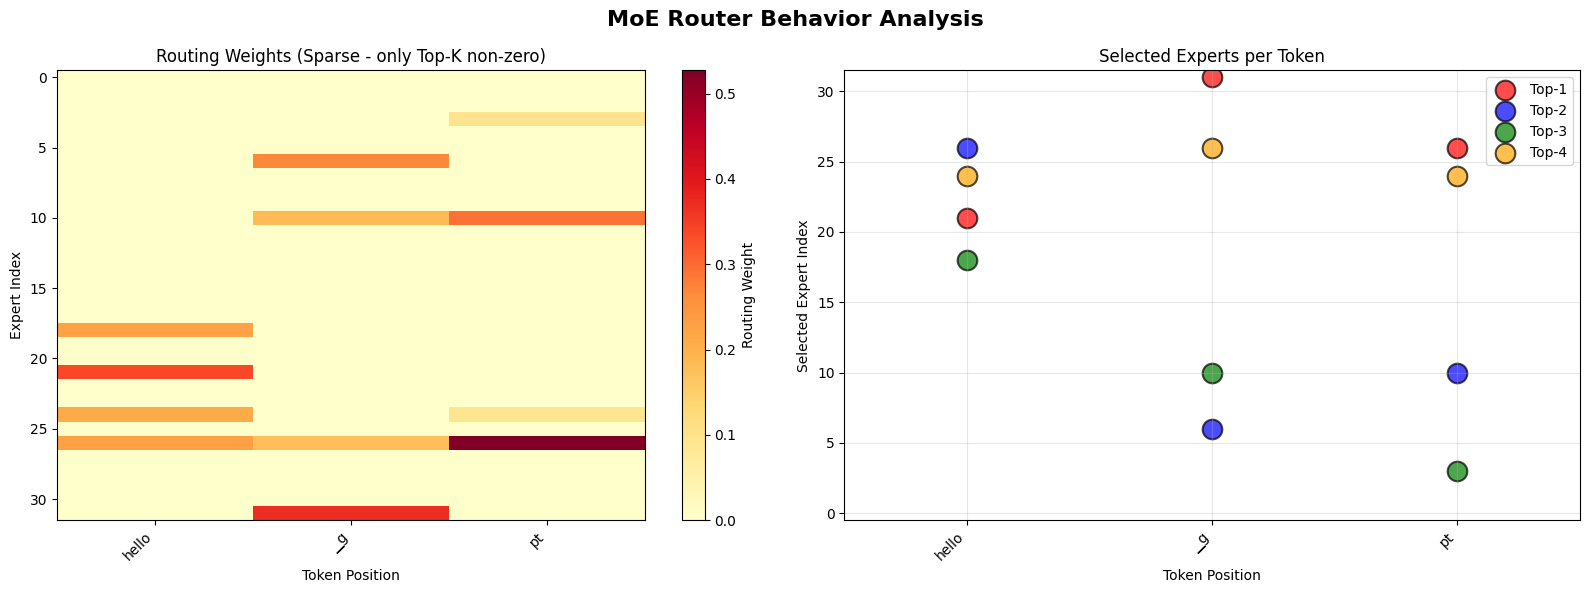


Detailed Router Decisions

Token 0: 'hello'
  Selected experts: [21, 26, 18, 24]
  Routing weights: ['0.3359', '0.2275', '0.2256', '0.2109']

Token 1: '▁g'
  Selected experts: [31, 6, 10, 26]
  Routing weights: ['0.3691', '0.2695', '0.1836', '0.1768']

Token 2: 'pt'
  Selected experts: [26, 10, 3, 24]
  Routing weights: ['0.5273', '0.2910', '0.0933', '0.0903']


In [ ]:
print("Analyzing router behavior...")

with torch.no_grad():
    normed = custom_decoder.post_norm(hidden_states)
    routing_weights, router_indices = custom_decoder.mlp.router(normed)

# Convert to numpy (router returns flattened, so already [batch*seq, num_experts])
routing_weights_np = routing_weights.cpu().float().numpy()  # [batch*seq, num_experts]
router_indices_np = router_indices.cpu().numpy()  # [batch*seq, top_k]

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('MoE Router Behavior Analysis', fontsize=16, fontweight='bold')

# 1. Routing weight heatmap
im1 = ax1.imshow(routing_weights_np.T, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax1.set_xlabel('Token Position')
ax1.set_ylabel('Expert Index')
ax1.set_title('Routing Weights (Sparse - only Top-K non-zero)')
ax1.set_xticks(range(len(tokens)))
ax1.set_xticklabels([t.replace('Ġ', '▁') for t in tokens], rotation=45, ha='right')
plt.colorbar(im1, ax=ax1, label='Routing Weight')

# 2. Selected experts per token
ax2.set_title('Selected Experts per Token')
ax2.set_xlabel('Token Position')
ax2.set_ylabel('Selected Expert Index')
ax2.set_xlim(-0.5, len(tokens) - 0.5)
ax2.set_ylim(-0.5, config.num_local_experts - 0.5)
ax2.set_xticks(range(len(tokens)))
ax2.set_xticklabels([t.replace('Ġ', '▁') for t in tokens], rotation=45, ha='right')
ax2.grid(True, alpha=0.3)

# Plot selected experts
colors = ['red', 'blue', 'green', 'orange']
for k in range(custom_decoder.mlp.router.top_k):
    expert_ids = router_indices_np[:, k]
    ax2.scatter(
        range(len(tokens)),
        expert_ids,
        c=colors[k % len(colors)],
        s=200,
        alpha=0.7,
        label=f'Top-{k+1}',
        edgecolors='black',
        linewidth=1.5
    )

ax2.legend()

plt.tight_layout()
plt.savefig('moe_router_analysis.png', dpi=150, bbox_inches='tight')
print("Saved visualization to 'moe_router_analysis.png'")
plt.show()

# Print detailed routing info
print("\n" + "=" * 60)
print("Detailed Router Decisions")
print("=" * 60)
for i, token in enumerate(tokens):
    print(f"\nToken {i}: '{token.replace('Ġ', '▁')}'")
    print(f"  Selected experts: {router_indices_np[i].tolist()}")
    selected_weights = routing_weights_np[i, router_indices_np[i]]
    print(f"  Routing weights: {[f'{w:.4f}' for w in selected_weights]}")

---

## 15. Summary and Key Takeaways

Congratulations! You have successfully implemented a complete Transformer Decoder Layer!

### Key Concepts Learned

1. **Mixture of Experts (MoE)**
   - Router selects Top-K experts per token
   - Experts computed in parallel (efficient!)
   - Sparse activation: only K out of N experts active
   - Better parameter efficiency

2. **Critical Implementation Detail: Interleaved Storage**
   ```python
   # CORRECT way (interleaved):
   gate = gate_up[..., ::2]   # Even indices
   up = gate_up[..., 1::2]     # Odd indices

   # WRONG way (blocked):
   mid = gate_up.shape[-1] // 2
   gate = gate_up[..., :mid]   # Will give wrong results!
   up = gate_up[..., mid:]      # Will give wrong results!
   ```
   **This is the #1 source of bugs in MoE implementations!**

3. **RMSNorm**
   - Efficient alternative to LayerNorm
   - No mean centering (just RMS normalization)
   - Better numerical stability
   - Used in modern LLMs

4. **Complete Decoder Layer Architecture**
   ```
   Input → RMSNorm → Attention → Residual
         → RMSNorm → MoE MLP → Residual → Output
   ```
   - Pre-normalization (norm before sub-layer)
   - Two residual connections
   - Attention + FFN = transformer block

5. **Gated Activation**
   ```python
   gate = gate_proj(x)
   up = up_proj(x)
   glu = gate * sigmoid(gate * alpha)
   output = (up + 1) * glu
   ```
   - Clamping for stability
   - Special alpha scaling (1.702)
   - Residual-like connection

### Verification Results

- ✓ Attention block: {attn_max_diff:.6e}
- ✓ MoE block: {mlp_max_diff:.6e}
- ✓ Complete layer: {layer_max_diff:.6e}
- All within tolerance: {tolerance:.0e}

### Implementation Checklist

- [x] RMSNorm with float32 computation
- [x] Router with Top-K selection
- [x] Experts with interleaved storage (CRITICAL!)
- [x] Gated activation with clamping
- [x] Parallel expert computation (BMM)
- [x] Attention with RoPE, GQA, Sinks
- [x] Residual connections
- [x] Pre-normalization
- [x] Complete layer integration
- [x] Block-by-block verification

### What's Next?

In the next tutorial, we will explore:
- **Stacking multiple layers**: Building the full transformer
- **KV-Cache**: Efficient autoregressive generation
- **Complete model**: Embedding → Layers → LM Head
- **Token generation**: Sampling strategies

### Practice Exercises

1. **Experiment with router behavior**:
   - Try different Top-K values
   - Analyze expert specialization
   - Plot expert utilization statistics

2. **Test interleaved vs blocked storage**:
   ```python
   # Try the WRONG way and see the difference!
   mid = gate_up.shape[-1] // 2
   gate_wrong = gate_up[..., :mid]
   up_wrong = gate_up[..., mid:]
   # Compare outputs - they will be VERY different!
   ```

3. **Visualize expert outputs**:
   - Compute individual expert outputs
   - Compare how different experts transform the same input
   - See specialization patterns

4. **Modify activation function**:
   - Try different alpha values
   - Experiment with different gating mechanisms
   - Compare performance

### References

- [Mixture of Experts](https://arxiv.org/abs/1701.06538) - Original MoE paper
- [Switch Transformer](https://arxiv.org/abs/2101.03961) - Google's scaled MoE
- [GLaM](https://arxiv.org/abs/2112.06905) - Generalist Language Model
- [RMSNorm](https://arxiv.org/abs/1910.07467) - Root Mean Square Layer Normalization

---

**Congratulations! You now have a complete, verified transformer decoder layer!**

Ready to stack these layers and build the full model? Let's continue!

In [ ]:
# Cleanup (optional)
print("\nCleaning up...")
import gc

del reference_model
del custom_decoder
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("GPU memory cleared")

print("Tutorial complete!")


Cleaning up...
Tutorial complete!
